# Probabilistic DDPM distribution / uncertainty analysis

This notebook turns DDPM inference from a single point estimate into an empirical predictive distribution.

For one selected LR condition image it repeatedly samples `diffusion.reverse_diffusion` (`N_SAMPLES`, e.g. 30 or 50), then computes:

- pixel-wise mean map
- pixel-wise variance map
- pixel-wise standard-deviation / uncertainty map
- normalized-space summaries
- optional counts-space restored maps
- radial morphology profiles with 1σ / 3σ error bands

Use this for model-native uncertainty: different DDPM reverse trajectories under the same condition quantify sampling uncertainty. Interpret it as epistemic/model-sampling uncertainty only if the trained model and noise schedule are appropriate; it is not automatically a calibrated experimental error bar.


In [1]:
from pathlib import Path
import importlib
import json
import math
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.colors import PowerNorm
from scipy.ndimage import map_coordinates
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "codes").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing both codes/ and data/.")


ADDR_ROOT = find_repo_root()
ADDR_CODE = ADDR_ROOT / "codes"
ADDR_MODELS = ADDR_CODE / "models"
for path in [ADDR_ROOT, ADDR_CODE, ADDR_MODELS]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.append(path_str)

from codes.config.config_DDPM import ModelConfig

print(f"ADDR_ROOT = {ADDR_ROOT}")
print(f"ADDR_CODE = {ADDR_CODE}")
print(f"CUDA available = {torch.cuda.is_available()}")


ADDR_ROOT = /root/LHAI_KM2A
ADDR_CODE = /root/LHAI_KM2A/codes
CUDA available = True


/root/miniconda3/envs/LHAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PREDICT_DIR = ADDR_ROOT / "data" / "Predict"
PREDICT_NPY_NAME = "HESSexcess_2_64_predict.npy"
PREDICT_NPY_PATH = None

SAMPLE_INDEX = 0
INPUT_CHANNEL = 1
TARGET_CHANNEL = 0
GT_NPY_PATH = None
GT_SAMPLE_INDEX = None

MODEL_WEIGHT_DIR = ADDR_ROOT / "saves" / "MODEL" / "DDPM"
MODEL_WEIGHT_NAME = "Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.pth"
MODEL_WEIGHT_PATH = None

DIFFUSION_CONFIG_KEY = "DDPM_64"
DIFFUSION_MODULE_NAME = "DDPM"
DIFFUSION_CLASS_NAME = "DDPM"
UNET_CONFIG_KEY = "UNET"
UNET_MODULE_NAME = "UNET"
UNET_CLASS_NAME = "UNET"

DATA_RANGE = 2.0
N_SAMPLES = 100
SAMPLE_BATCH_SIZE = 50
BASE_SEED = 2026
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
STRICT_LOAD = True
CLAMP_OUTPUT = False
OVERRIDE_IMG_SIZE_FROM_DATA = True

COUNTS_RESTORE_MODE = "input_mass_match"
COUNTS_REFERENCE_MODE = "input"
CLIP_FOR_COUNTS = True
EPS_COUNTS = 1e-8

RADIAL_CENTER_MODE = "target_peak"
RADIAL_CENTER_YX = None
RADIAL_BIN_WIDTH = 1.0
RADIAL_N_SIGMA = 1
RADIAL_USE_COUNTS = True

VIS_CMAP_IMAGE = "viridis"
VIS_CMAP_UNCERTAINTY = "inferno"
ENHANCED_COUNTS_STYLE = True
SAVE_OUTPUTS = True
OUTPUT_DIR = ADDR_ROOT / "saves" / "PREDICT" / "DDPM" / "ProbDistribution"


In [3]:
def show_available_files():
    predict_files = sorted(PREDICT_DIR.glob("*.npy")) if PREDICT_DIR.exists() else []
    weight_files = sorted(MODEL_WEIGHT_DIR.glob("*.pth")) if MODEL_WEIGHT_DIR.exists() else []
    print("Available predict .npy files:")
    for path in predict_files:
        print(f"  {path.name}")
    if not predict_files:
        print(f"  No .npy files found in {PREDICT_DIR}; set PREDICT_NPY_PATH manually if needed.")
    print("\nAvailable DDPM weights:")
    for path in weight_files:
        print(f"  {path.name}")
    if not weight_files:
        print(f"  No .pth files found in {MODEL_WEIGHT_DIR}; set MODEL_WEIGHT_PATH manually if needed.")
    print("\nConfig hints:")
    print("  64x64 DDPM: DIFFUSION_CONFIG_KEY = 'DDPM_64'")
    print("  128x128 DDPM/SR: DIFFUSION_CONFIG_KEY = 'DDPM128'")
    print("  If PREDICT_NPY has shape (N,H,W), SAMPLE_INDEX selects the image.")
    print("  If PREDICT_NPY has shape (N,C,H,W), INPUT_CHANNEL selects the condition channel if needed.")


show_available_files()

if PREDICT_NPY_PATH is None:
    if PREDICT_NPY_NAME is None:
        raise ValueError("Set PREDICT_NPY_NAME or PREDICT_NPY_PATH in the configuration cell.")
    predict_path = PREDICT_DIR / PREDICT_NPY_NAME
else:
    predict_path = Path(PREDICT_NPY_PATH)

if MODEL_WEIGHT_PATH is None:
    if MODEL_WEIGHT_NAME is None:
        raise ValueError("Set MODEL_WEIGHT_NAME or MODEL_WEIGHT_PATH in the configuration cell.")
    model_weight_path = MODEL_WEIGHT_DIR / MODEL_WEIGHT_NAME
else:
    model_weight_path = Path(MODEL_WEIGHT_PATH)

if not predict_path.exists():
    raise FileNotFoundError(predict_path)
if not model_weight_path.exists():
    raise FileNotFoundError(model_weight_path)

print(f"Selected predict data: {predict_path}")
print(f"Selected model weight: {model_weight_path}")


Available predict .npy files:
  ECAexcess_300_64_test.npy
  HESS_2_64_Predict_conv.npy
  HESS_2_64_Predict_version2poissonexcess.npy
  HESSbkgon_2_128_predict.npy
  HESSbkgon_2_64_predict.npy
  HESSexcess_2_128_predict.npy
  HESSexcess_2_64_predict.npy
  HESSpoisonon_2_128_predict.npy
  HESSpoisonon_2_64_predict.npy
  RSAexcess_500_64_test.npy

Available DDPM weights:
  Best_DDPM_EXP01_2epo_32bth_SR4poissonexcess.pth
  Best_DDPM_EXP01_400epo_128bth_KM2A4eval.pth
  Best_DDPM_KM2AE25_100epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25_2epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25_400epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25v2_1000epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2AE25v2_600epo_64bth_KM2A4poisonexcess.pth
  Best_DDPM_KM2A_1000epo_32bth_SR4poissonexcess.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonexcess.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonexcess_finetuned.pth
  Best_DDPM_KM2A_400epo_32bth_SR4poissonexcess_finetuned400epo.pth
  Best_DDPM_KM2A_400epo_

In [4]:
def _as_float32(array):
    return np.asarray(array, dtype=np.float32)


def _select_image_from_array(array, sample_index=0, channel=None, role="input"):
    array = np.asarray(array)
    if array.ndim == 2:
        return _as_float32(array)
    if array.ndim == 3:
        if array.shape[0] <= 8 and array.shape[1] == array.shape[2] and channel is not None:
            return _as_float32(array[channel])
        if sample_index >= array.shape[0]:
            raise IndexError(f"{role}: SAMPLE_INDEX={sample_index} out of range for shape {array.shape}")
        return _as_float32(array[sample_index])
    if array.ndim == 4:
        if sample_index >= array.shape[0]:
            raise IndexError(f"{role}: SAMPLE_INDEX={sample_index} out of range for shape {array.shape}")
        sample = array[sample_index]
        if channel is None:
            if sample.shape[0] == 1:
                channel = 0
            elif sample.shape[0] >= 2:
                channel = 1 if role == "input" else 0
            else:
                raise ValueError(f"{role}: cannot infer channel for shape {array.shape}")
        return _as_float32(sample[channel])
    raise ValueError(f"{role}: expected shape (H,W), (N,H,W), (C,H,W), or (N,C,H,W), got {array.shape}")


def minmax_normalize_image(image, data_range=1.0):
    image = _as_float32(image)
    vmin = float(np.min(image))
    vmax = float(np.max(image))
    norm01 = (image - vmin) / max(vmax - vmin, 1e-8)
    if abs(data_range - 1.0) < 1e-6:
        return norm01.astype(np.float32), vmin, vmax
    if abs(data_range - 2.0) < 1e-6:
        return (2.0 * norm01 - 1.0).astype(np.float32), vmin, vmax
    raise ValueError("DATA_RANGE must be 1.0 or 2.0")


def normalized_to_unit_interval(array):
    array = np.asarray(array, dtype=np.float32)
    if abs(DATA_RANGE - 2.0) < 1e-6:
        unit = 0.5 * (array + 1.0)
    elif abs(DATA_RANGE - 1.0) < 1e-6:
        unit = array
    else:
        raise ValueError("DATA_RANGE must be 1.0 or 2.0")
    return np.clip(unit, 0.0, 1.0) if CLIP_FOR_COUNTS else unit


def resize_2d(image, size):
    image = _as_float32(image)
    if image.shape == (size, size):
        return image
    tensor = torch.from_numpy(image[None, None]).float()
    return F.interpolate(tensor, size=(size, size), mode="bilinear", align_corners=False)[0, 0].numpy()


predict_array = np.load(predict_path, allow_pickle=True)
input_counts = _select_image_from_array(predict_array, SAMPLE_INDEX, INPUT_CHANNEL, role="input")
input_norm, input_min, input_max = minmax_normalize_image(input_counts, DATA_RANGE)

target_counts = None
if GT_NPY_PATH is not None:
    gt_array = np.load(Path(GT_NPY_PATH), allow_pickle=True)
    gt_idx = SAMPLE_INDEX if GT_SAMPLE_INDEX is None else GT_SAMPLE_INDEX
    target_counts = _select_image_from_array(gt_array, gt_idx, TARGET_CHANNEL, role="target")
elif np.asarray(predict_array).ndim == 4 and np.asarray(predict_array).shape[1] >= 2:
    target_counts = _select_image_from_array(predict_array, SAMPLE_INDEX, 0 if TARGET_CHANNEL is None else TARGET_CHANNEL, role="target")

target_norm = None
if target_counts is not None:
    target_norm, target_min, target_max = minmax_normalize_image(target_counts, DATA_RANGE)

print(f"predict array shape: {np.asarray(predict_array).shape}")
print(f"selected input shape: {input_counts.shape}, min={input_counts.min():.4g}, max={input_counts.max():.4g}, sum={input_counts.sum():.4g}")
if target_counts is not None:
    print(f"selected GT shape: {target_counts.shape}, min={target_counts.min():.4g}, max={target_counts.max():.4g}, sum={target_counts.sum():.4g}")
else:
    print("No GT target provided; uncertainty analysis will omit GT comparison panels/profiles.")


predict array shape: (2, 2, 64, 64)
selected input shape: (64, 64), min=32.54, max=1772, sum=2.643e+05
selected GT shape: (64, 64), min=0, max=2920, sum=6.112e+04


In [5]:
def import_model_class(module_name, class_name):
    module = importlib.import_module(f"codes.models.{module_name}")
    return getattr(module, class_name)


model_cfg = ModelConfig()
model_params = model_cfg.model_params
condition_size = int(input_norm.shape[-1])
if input_norm.shape[-1] != input_norm.shape[-2]:
    raise ValueError(f"Input image must be square for current DDPM implementation, got {input_norm.shape}")

if DIFFUSION_CONFIG_KEY is None:
    if condition_size == 128 and "DDPM128" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM128"
    elif condition_size == 64 and "DDPM_64" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM_64"
    elif "DDPM" in model_params:
        DIFFUSION_CONFIG_KEY = "DDPM"
    else:
        raise KeyError("Could not infer DIFFUSION_CONFIG_KEY. Set it manually.")

if DIFFUSION_CONFIG_KEY not in model_params:
    raise KeyError(f"{DIFFUSION_CONFIG_KEY=} not found in ModelConfig.model_params")
if UNET_CONFIG_KEY not in model_params:
    raise KeyError(f"{UNET_CONFIG_KEY=} not found in ModelConfig.model_params")

params_diffusion = dict(model_params[DIFFUSION_CONFIG_KEY])
params_unet = dict(model_params[UNET_CONFIG_KEY])
image_size = int(params_diffusion.get("img_size", condition_size))
if OVERRIDE_IMG_SIZE_FROM_DATA and params_diffusion.get("img_size") != condition_size:
    print(f"Overriding diffusion img_size from {params_diffusion.get('img_size')} to input condition size {condition_size}.")
    image_size = condition_size
    params_diffusion["img_size"] = image_size
params_diffusion["device"] = torch.device(DEVICE)

device = torch.device(DEVICE)
DIFFUSION = import_model_class(DIFFUSION_MODULE_NAME, DIFFUSION_CLASS_NAME)
UNET = import_model_class(UNET_MODULE_NAME, UNET_CLASS_NAME)

diffusion = DIFFUSION(**params_diffusion)
unet = UNET(**params_unet).to(device)
if hasattr(unet, "build"):
    unet.build()
unet.to(device)
state = torch.load(model_weight_path, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
unet.load_state_dict(state, strict=STRICT_LOAD)
unet.eval()

condition_norm = resize_2d(input_norm, image_size)
condition_tensor = torch.from_numpy(condition_norm[None, None]).float().to(device)
target_counts_resized = resize_2d(target_counts, image_size) if target_counts is not None else None
input_counts_resized = resize_2d(input_counts, image_size)

# ===== 新增：方案 B - 物理通量对齐 (Flux Matching) =====
if target_counts_resized is not None:
    input_flux = float(np.sum(input_counts_resized))
    target_flux = float(np.sum(target_counts_resized))
    
    if target_flux > 1e-8:
        scale_factor = input_flux / target_flux
        target_counts_resized = target_counts_resized * scale_factor
        
        print(f"\n[Flux Alignment] Applied Option B: Scaled Ground Truth to match Input observation.")
        print(f"[Flux Alignment] Scale factor: {scale_factor:.4f}")
        print(f"[Flux Alignment] New GT sum: {target_counts_resized.sum():.4g} (Matched to Input sum: {input_flux:.4g})")
# =======================================================

print(f"Device: {device}")
print(f"Diffusion config key: {DIFFUSION_CONFIG_KEY}")
print(f"Image size: {image_size}")
print(f"Condition tensor shape: {tuple(condition_tensor.shape)}")


[Flux Alignment] Applied Option B: Scaled Ground Truth to match Input observation.
[Flux Alignment] Scale factor: 4.3245
[Flux Alignment] New GT sum: 2.643e+05 (Matched to Input sum: 2.643e+05)
Device: cuda
Diffusion config key: DDPM_64
Image size: 64
Condition tensor shape: (1, 1, 64, 64)


In [6]:
def reduce_generated(generated):
    if generated.dim() == 5:
        if generated.shape[0] == 1:
            generated = generated[:, -1]
        else:
            generated = generated[-1]
    if CLAMP_OUTPUT:
        if abs(DATA_RANGE - 1.0) < 1e-6:
            generated = generated.clamp(0.0, 1.0)
        else:
            generated = generated.clamp(-1.0, 1.0)
    return generated


def restore_samples_to_counts(samples_norm, reference_mode=COUNTS_REFERENCE_MODE, restore_mode=COUNTS_RESTORE_MODE):
    unit = normalized_to_unit_interval(samples_norm)
    if restore_mode == "input_minmax":
        return unit * max(input_max - input_min, EPS_COUNTS) + input_min
    if restore_mode == "input_mass_match":
        reference = np.clip(input_counts_resized, 0.0, None)
    elif restore_mode == "target_mass_match":
        if target_counts_resized is None:
            raise ValueError("target_mass_match requires GT target.")
        reference = np.clip(target_counts_resized, 0.0, None)
    else:
        raise ValueError("COUNTS_RESTORE_MODE must be input_minmax, input_mass_match, or target_mass_match")
    unit_pos = np.clip(unit, 0.0, None)
    ref_mass = reference.sum()
    unit_mass = unit_pos.reshape(unit_pos.shape[0], -1).sum(axis=1).reshape((-1, 1, 1))
    return unit_pos * (ref_mass / np.maximum(unit_mass, EPS_COUNTS))


samples_norm = []
with torch.no_grad():
    for start in tqdm(range(0, N_SAMPLES, SAMPLE_BATCH_SIZE), desc="Repeated DDPM samples"):
        current_batch = min(SAMPLE_BATCH_SIZE, N_SAMPLES - start)
        batch_condition = condition_tensor.repeat(current_batch, 1, 1, 1)
        for local_i in range(current_batch):
            seed = BASE_SEED + start + local_i
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
        generated = diffusion.reverse_diffusion(
            model=unet,
            n_images=current_batch,
            n_channels=1,
            input_image=batch_condition,
            save_time_steps=None,
        )
        generated = reduce_generated(generated).detach().cpu().numpy()[:, 0]
        samples_norm.append(generated)
        del generated, batch_condition
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

samples_norm = np.concatenate(samples_norm, axis=0).astype(np.float32)
mean_norm = samples_norm.mean(axis=0)
var_norm = samples_norm.var(axis=0, ddof=1 if samples_norm.shape[0] > 1 else 0)
std_norm = np.sqrt(var_norm)

samples_counts = restore_samples_to_counts(samples_norm)
mean_counts = samples_counts.mean(axis=0)
var_counts = samples_counts.var(axis=0, ddof=1 if samples_counts.shape[0] > 1 else 0)
std_counts = np.sqrt(var_counts)

print(f"samples_norm shape: {samples_norm.shape}")
print(f"normalized mean/std ranges: mean=({mean_norm.min():.4g}, {mean_norm.max():.4g}), std=({std_norm.min():.4g}, {std_norm.max():.4g})")
print(f"counts mean/std ranges: mean=({mean_counts.min():.4g}, {mean_counts.max():.4g}), std=({std_counts.min():.4g}, {std_counts.max():.4g})")


Repeated DDPM samples: 100%|██████████| 2/2 [00:10<00:00,  5.05s/it]

samples_norm shape: (100, 64, 64)
normalized mean/std ranges: mean=(-1.003, 0.4324), std=(0.002263, 0.6092)
counts mean/std ranges: mean=(2.592, 8137), std=(4.769, 2768)


Saved map figure: /root/LHAI_KM2A/saves/PREDICT/DDPM/ProbDistribution/prob_maps__HESSexcess_2_64_predict__idx0__Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.png


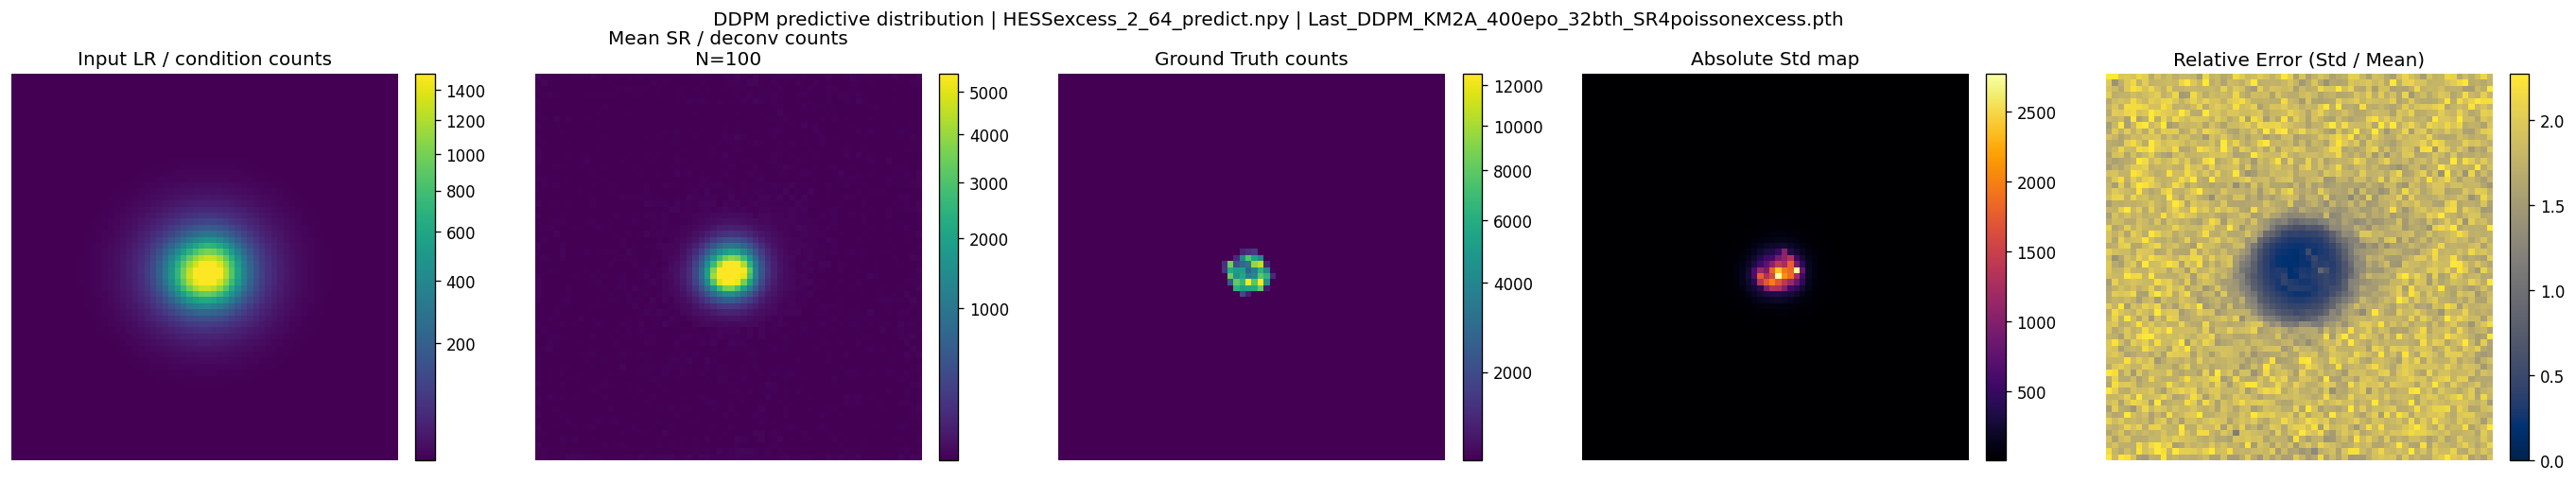

In [7]:
def get_display_limits(image, floor_percentile=50, ceil_percentile=99.7):
    positive = image[np.isfinite(image) & (image > 0)]
    if positive.size == 0:
        finite = image[np.isfinite(image)]
        if finite.size == 0:
            return 0.0, 1.0
        return float(np.nanmin(finite)), float(np.nanmax(finite) + 1e-6)
    vmin = float(np.percentile(positive, floor_percentile))
    vmax = float(np.percentile(positive, ceil_percentile))
    if vmax <= vmin:
        vmax = float(positive.max())
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax


def imshow_counts(ax, image, title, cmap=VIS_CMAP_IMAGE, enhanced=ENHANCED_COUNTS_STYLE):
    if enhanced:
        vmin, vmax = get_display_limits(image)
        im = ax.imshow(image, origin="lower", cmap=cmap, norm=PowerNorm(gamma=0.55, vmin=vmin, vmax=vmax), interpolation="nearest")
    else:
        im = ax.imshow(image, origin="lower", cmap=cmap, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im

# ==========================================
# 1. 计算相对不确定度 (Relative Uncertainty)
# ==========================================
eps = 1e-8
# 相对误差 = 标准差 / 绝对均值
rel_std = std_counts / (np.abs(mean_counts) + eps)

# ==========================================
# 2. 动态调整列数 (GT存在则为5列，否则为4列)
# ==========================================
ncols = 5 if target_counts_resized is not None else 4
fig, axes = plt.subplots(1, ncols, figsize=(4.6 * ncols, 4.2), squeeze=False)
axes = axes[0]

# --- 第一列：模糊输入 ---
imshow_counts(axes[0], input_counts_resized, "Input LR / condition counts", cmap=VIS_CMAP_IMAGE)

# --- 第二列：DDPM 均值超分 ---
imshow_counts(axes[1], mean_counts, f"Mean SR / deconv counts\nN={N_SAMPLES}", cmap=VIS_CMAP_IMAGE)

# --- 第三列：Ground Truth (如果存在) ---
if target_counts_resized is not None:
    imshow_counts(axes[2], target_counts_resized, "Ground Truth counts", cmap=VIS_CMAP_IMAGE)
    std_idx = 3
else:
    std_idx = 2

# --- 第四列：绝对标准差图 (Absolute Std) ---
im_std = axes[std_idx].imshow(std_counts, origin="lower", cmap=VIS_CMAP_UNCERTAINTY, interpolation="nearest")
axes[std_idx].set_title("Absolute Std map")
axes[std_idx].axis("off")
plt.colorbar(im_std, ax=axes[std_idx], fraction=0.046, pad=0.04)

# --- 第五列：相对不确定度图 (Relative Error) ---
rel_idx = std_idx + 1
# 为了防止暗弱背景区的除零或极大值毁掉色标，截取98%分位数或最大值为3.0 (即300%相对误差)
vmax_rel = min(float(np.percentile(rel_std, 98)), 3.0)

# 建议相对误差使用不同的色标，比如 'cividis' 或 'magma'
im_rel = axes[rel_idx].imshow(rel_std, origin="lower", cmap="cividis", vmin=0, vmax=vmax_rel, interpolation="nearest")
axes[rel_idx].set_title("Relative Error (Std / Mean)")
axes[rel_idx].axis("off")
plt.colorbar(im_rel, ax=axes[rel_idx], fraction=0.046, pad=0.04)

# ==========================================
# 3. 总体排版与保存
# ==========================================
fig.suptitle(f"DDPM predictive distribution | {predict_path.name} | {model_weight_path.name}")
fig.tight_layout()

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = OUTPUT_DIR / f"prob_maps__{predict_path.stem}__idx{SAMPLE_INDEX}__{model_weight_path.stem}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved map figure: {fig_path}")

plt.show()

Saved radial profile: /root/LHAI_KM2A/saves/PREDICT/DDPM/ProbDistribution/radial_profile_uncertainty__HESSexcess_2_64_predict__idx0__Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.png


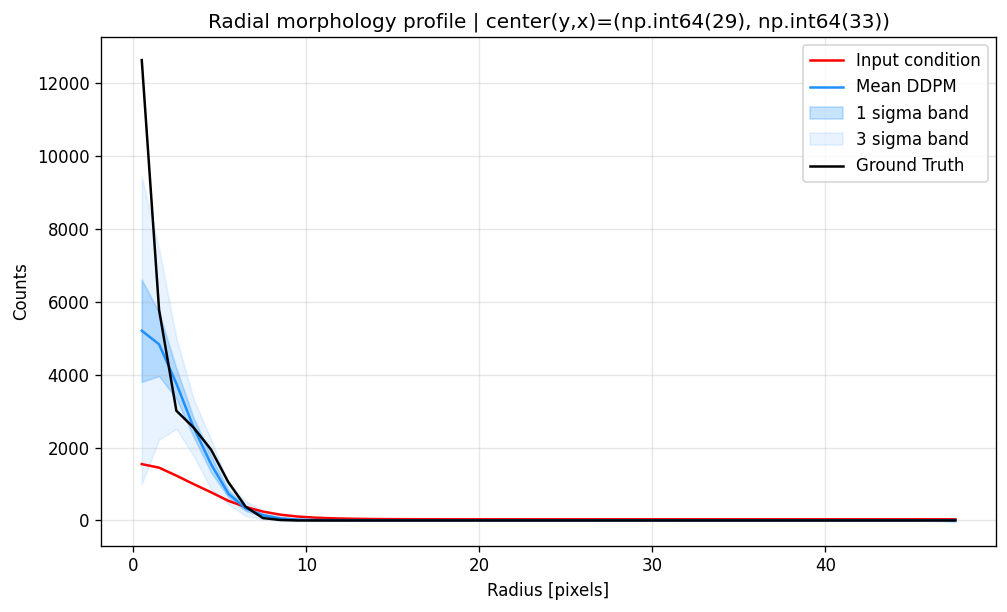

In [8]:
def choose_center():
    if RADIAL_CENTER_YX is not None:
        return tuple(RADIAL_CENTER_YX)
    if RADIAL_CENTER_MODE == "target_peak" and target_counts_resized is not None:
        return np.unravel_index(int(np.nanargmax(target_counts_resized)), target_counts_resized.shape)
    if RADIAL_CENTER_MODE == "mean_peak":
        image = mean_counts if RADIAL_USE_COUNTS else mean_norm
        return np.unravel_index(int(np.nanargmax(image)), image.shape)
    if RADIAL_CENTER_MODE == "input_peak":
        return np.unravel_index(int(np.nanargmax(input_counts_resized)), input_counts_resized.shape)
    raise ValueError("RADIAL_CENTER_MODE must be target_peak, mean_peak, input_peak, or set RADIAL_CENTER_YX manually.")


def radial_profile_samples(samples, center_yx, bin_width=1.0):
    samples = np.asarray(samples, dtype=np.float64)
    h, w = samples.shape[-2:]
    yy, xx = np.indices((h, w))
    rr = np.sqrt((yy - center_yx[0]) ** 2 + (xx - center_yx[1]) ** 2)
    bin_index = np.floor(rr / bin_width).astype(int)
    nbins = int(bin_index.max()) + 1
    profiles = np.full((samples.shape[0], nbins), np.nan, dtype=np.float64)
    for b in range(nbins):
        mask = bin_index == b
        if np.any(mask):
            profiles[:, b] = samples[:, mask].mean(axis=1)
    radii = (np.arange(nbins) + 0.5) * bin_width
    return radii, profiles


profile_samples = samples_counts if RADIAL_USE_COUNTS else samples_norm
profile_input = input_counts_resized if RADIAL_USE_COUNTS else condition_norm
profile_target = target_counts_resized if (RADIAL_USE_COUNTS and target_counts_resized is not None) else target_norm
if profile_target is not None and profile_target.shape != profile_input.shape:
    profile_target = resize_2d(profile_target, image_size)

center_yx = choose_center()
radii, sample_profiles = radial_profile_samples(profile_samples, center_yx, RADIAL_BIN_WIDTH)
mean_profile = np.nanmean(sample_profiles, axis=0)
std_profile = np.nanstd(sample_profiles, axis=0, ddof=1 if sample_profiles.shape[0] > 1 else 0)
_, input_profile_samples = radial_profile_samples(profile_input[None], center_yx, RADIAL_BIN_WIDTH)
input_profile = input_profile_samples[0]
if profile_target is not None:
    _, target_profile_samples = radial_profile_samples(profile_target[None], center_yx, RADIAL_BIN_WIDTH)
    target_profile = target_profile_samples[0]
else:
    target_profile = None

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(radii, input_profile, color="red", label="Input condition")
ax.plot(radii, mean_profile, color="dodgerblue", label="Mean DDPM")
ax.fill_between(
    radii,
    mean_profile - RADIAL_N_SIGMA * std_profile,
    mean_profile + RADIAL_N_SIGMA * std_profile,
    color="dodgerblue",
    alpha=0.25,
    label=f"{RADIAL_N_SIGMA} sigma band",
)
if RADIAL_N_SIGMA != 3:
    ax.fill_between(radii, mean_profile - 3 * std_profile, mean_profile + 3 * std_profile, color="dodgerblue", alpha=0.10, label="3 sigma band")
if target_profile is not None:
    ax.plot(radii, target_profile, color="black", label="Ground Truth")
ax.set_xlabel("Radius [pixels]")
ax.set_ylabel("Counts" if RADIAL_USE_COUNTS else f"Normalized intensity ({DATA_RANGE=})")
ax.set_title(f"Radial morphology profile | center(y,x)={center_yx}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = OUTPUT_DIR / f"radial_profile_uncertainty__{predict_path.stem}__idx{SAMPLE_INDEX}__{model_weight_path.stem}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved radial profile: {fig_path}")
plt.show()


In [9]:
def summarize_uncertainty():
    eps = 1e-8
    if target_counts_resized is not None:
        bright_threshold = np.percentile(target_counts_resized[target_counts_resized > 0], 90) if np.any(target_counts_resized > 0) else np.percentile(target_counts_resized, 90)
        faint_threshold = np.percentile(target_counts_resized, 50)
        bright_mask = target_counts_resized >= bright_threshold
        faint_mask = target_counts_resized <= faint_threshold
    else:
        bright_threshold = np.percentile(mean_counts[mean_counts > 0], 90) if np.any(mean_counts > 0) else np.percentile(mean_counts, 90)
        faint_threshold = np.percentile(mean_counts, 50)
        bright_mask = mean_counts >= bright_threshold
        faint_mask = mean_counts <= faint_threshold
    relative_std = std_counts / (np.abs(mean_counts) + eps)
    payload = {
        "n_samples": int(N_SAMPLES),
        "data_path": str(predict_path),
        "sample_index": int(SAMPLE_INDEX),
        "model_weight_path": str(model_weight_path),
        "diffusion_config_key": DIFFUSION_CONFIG_KEY,
        "data_range": DATA_RANGE,
        "counts_restore_mode": COUNTS_RESTORE_MODE,
        "radial_center_yx": [int(center_yx[0]), int(center_yx[1])],
        "mean_std_counts_all_pixels": float(np.mean(std_counts)),
        "median_relative_std_all_pixels": float(np.median(relative_std)),
        "mean_std_bright_region": float(np.mean(std_counts[bright_mask])),
        "mean_std_faint_region": float(np.mean(std_counts[faint_mask])),
        "median_relative_std_bright_region": float(np.median(relative_std[bright_mask])),
        "median_relative_std_faint_region": float(np.median(relative_std[faint_mask])),
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    if target_counts_resized is not None:
        payload["mean_counts_mae_to_gt"] = float(np.mean(np.abs(mean_counts - target_counts_resized)))
        payload["mean_counts_rmse_to_gt"] = float(np.sqrt(np.mean((mean_counts - target_counts_resized) ** 2)))
    return payload


uncertainty_summary = summarize_uncertainty()
print(json.dumps(uncertainty_summary, ensure_ascii=False, indent=2))

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    stem = f"{predict_path.stem}__idx{SAMPLE_INDEX}__{model_weight_path.stem}"
    np.save(OUTPUT_DIR / f"samples_norm__{stem}.npy", samples_norm.astype(np.float32))
    np.save(OUTPUT_DIR / f"mean_norm__{stem}.npy", mean_norm.astype(np.float32))
    np.save(OUTPUT_DIR / f"std_norm__{stem}.npy", std_norm.astype(np.float32))
    np.save(OUTPUT_DIR / f"mean_counts__{stem}.npy", mean_counts.astype(np.float32))
    np.save(OUTPUT_DIR / f"std_counts__{stem}.npy", std_counts.astype(np.float32))
    (OUTPUT_DIR / f"uncertainty_summary__{stem}.json").write_text(json.dumps(uncertainty_summary, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved arrays and summary under: {OUTPUT_DIR}")


{
  "n_samples": 100,
  "data_path": "/root/LHAI_KM2A/data/Predict/HESSexcess_2_64_predict.npy",
  "sample_index": 0,
  "model_weight_path": "/root/LHAI_KM2A/saves/MODEL/DDPM/Last_DDPM_KM2A_400epo_32bth_SR4poissonexcess.pth",
  "diffusion_config_key": "DDPM_64",
  "data_range": 2.0,
  "counts_restore_mode": "input_mass_match",
  "radial_center_yx": [
    29,
    33
  ],
  "mean_std_counts_all_pixels": 27.527265548706055,
  "median_relative_std_all_pixels": 1.7994909286499023,
  "mean_std_bright_region": 1319.4375,
  "mean_std_faint_region": 11.349828720092773,
  "median_relative_std_bright_region": 0.28857213258743286,
  "median_relative_std_faint_region": 1.8059203624725342,
  "created_at": "2026-06-28T16:50:53",
  "mean_counts_mae_to_gt": 42.093162536621094,
  "mean_counts_rmse_to_gt": 344.83599853515625
}
Saved arrays and summary under: /root/LHAI_KM2A/saves/PREDICT/DDPM/ProbDistribution
